# Modelling

**Input:** `data/processed/analysis_ready.pkl` + `data/processed/feature_sets.json`  
**Output:** `data/processed/model_predictions.pkl` - out-of-fold and held-out test predictions for notebook 04

### Design

| Decision | Choice | Rationale |
|----------|--------|-----------|
| Held-out test set | 20% stratified split | Guarantees final evaluation on data never seen during any training or tuning step |
| CV within training set | 5-fold stratified | OOF predictions cover all training participants; folds also used for Optuna tuning |
| Optuna objective | Brier score (not AUC) | Optimises calibration - miscalibrated probabilities distort decision curve thresholds |
| Imputation | Median fit on train fold only | Prevents leakage from validation data into imputation values |
| TabPFN training cap | 10,000 samples | Prior-fitted transformer with a practical training size limit; subsampled if exceeded |

### Notebook outline

| Step | Description |
|------|-------------|
| 1. Load | Read analysis-ready data and feature sets |
| 2. Split | Stratified 80/20 train/test split |
| 3. LightGBM | Optuna-tuned LightGBM across CV folds |
| 4. TabPFN | TabPFN across CV folds with size cap |
| 5. Run | All 6 model × feature set combinations |
| 6. Metrics | AUC and Brier score summary table |
| 7. Calibration | Calibration curves for all models |
| 8. Save | Predictions for notebook 04 |

In [16]:
%cd ~/Documents/biomarker-actionability

/Users/mkopy/Documents/biomarker-actionability


**TabPFN API token** - set `TABPFN_TOKEN` in the environment before running this notebook. 
The recommended approach is a `.env` file in the project root (already gitignored):

```
TABPFN_TOKEN=your_token_here
```

Then load it with `python-dotenv` or export it in your shell before launching Jupyter. 
**Never hardcode the token in the notebook.**

In [17]:
import pandas as pd
import numpy as np
import json
import os

# TabPFN API key - do not commit to a public repo
os.environ["TABPFN_TOKEN"] = os.getenv("TABPFN_TOKEN", "")

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

pd.options.future.infer_string = False

from src.features import BIOLOGICAL_FEATURES, DIGITAL_FEATURES, COMBINED_FEATURES, TARGETS
from src.models import train_lgbm, eval_lgbm_on_test, train_tabpfn, eval_tabpfn_on_test

## 1. Load Data

In [18]:
df = pd.read_pickle('data/processed/analysis_ready.pkl')

TARGET = TARGETS[0]  # 'cvd_hard' - primary outcome; composite used as sensitivity in notebook 04

print(f"Samples    : {len(df):,}")
print(f"Features   : biological={len(BIOLOGICAL_FEATURES)}, digital={len(DIGITAL_FEATURES)}, combined={len(COMBINED_FEATURES)}")
print(f"Prevalence : {df[TARGET].mean():.1%}  ({df[TARGET].sum():,} hard CVD cases)")

Samples    : 4,836
Features   : biological=19, digital=8, combined=27
Prevalence : 7.5%  (363 hard CVD cases)


## 2. Train / Test Split

Hold out 20% of participants as a true test set. **No model - including Optuna tuning - ever sees this data.** Cross-validation and all hyperparameter search happen entirely within the training set.

The test set provides the final unbiased performance estimate reported in results. OOF predictions on the training set feed into notebook 04 for decision curve analysis.

In [19]:
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df[TARGET]
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df):,}  ({train_df[TARGET].mean():.1%} prevalence)")
print(f"Test  : {len(test_df):,}  ({test_df[TARGET].mean():.1%} prevalence)")

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

Train : 3,868  (7.5% prevalence)
Test  : 968  (7.5% prevalence)


## 3. LightGBM

Optuna tunes hyperparameters within each CV fold using Brier score as the objective. The final model for each fold is refit with the best params found for that fold and used to generate OOF predictions.

After CV, a final model is trained on the full training set (best params from the last fold as a reasonable proxy) and evaluated on the held-out test set.

In [20]:
# Training functions live in src/models.py:
#   train_lgbm(train_df, feature_cols, target, n_trials=50, cv=None)
#   eval_lgbm_on_test(train_df, test_df, feature_cols, target, best_params)
#   train_tabpfn(train_df, feature_cols, target, cv=None)
#   eval_tabpfn_on_test(train_df, test_df, feature_cols, target)

## 4. TabPFN

TabPFN is a prior-fitted transformer that requires no hyperparameter tuning but has a practical training size limit (~10,000 samples). If a fold's training set exceeds this, a stratified subsample is drawn - this is documented per run.

TabPFN does not support missing values natively; median imputation (fit on train fold) is applied before each fold.

## 5. Run All Combinations

Six model × feature set combinations: LightGBM and TabPFN each on biological, digital, and combined features. OOF predictions are generated on the training set; test set predictions are generated from a model trained on all training data.

In [21]:
FEATURE_SETS = {
    'biological': BIOLOGICAL_FEATURES,
    'digital':    DIGITAL_FEATURES,
    'combined':   COMBINED_FEATURES,
}

oof_results  = {}  # train-set OOF predictions
test_results = {}  # held-out test predictions
lgbm_params  = {}  # best params per feature set (for retraining)

for fs_name, feature_cols in FEATURE_SETS.items():
    print(f"\n{'='*54}")
    print(f"Feature set: {fs_name}  ({len(feature_cols)} features)")
    print(f"{'='*54}")

    print("\nLightGBM:")
    oof_preds, best_params = train_lgbm(train_df, feature_cols, TARGET, n_trials=50)
    oof_results[f'lgbm_{fs_name}']  = oof_preds
    lgbm_params[fs_name]            = best_params
    test_results[f'lgbm_{fs_name}'] = eval_lgbm_on_test(train_df, test_df, feature_cols, TARGET, best_params)

    print("\nTabPFN:")
    oof_preds = train_tabpfn(train_df, feature_cols, TARGET)
    oof_results[f'tabpfn_{fs_name}']  = oof_preds
    test_results[f'tabpfn_{fs_name}'] = eval_tabpfn_on_test(train_df, test_df, feature_cols, TARGET)


Feature set: biological  (19 features)

LightGBM:
  Fold 1: Brier=0.0531  AUC=0.8690
  Fold 2: Brier=0.0581  AUC=0.8154
  Fold 3: Brier=0.0542  AUC=0.8855
  Fold 4: Brier=0.0615  AUC=0.8059
  Fold 5: Brier=0.0545  AUC=0.8791

TabPFN:
  Fold 1: Brier=0.0535  AUC=0.8753
  Fold 2: Brier=0.0591  AUC=0.8440
  Fold 3: Brier=0.0512  AUC=0.9012
  Fold 4: Brier=0.0609  AUC=0.8288
  Fold 5: Brier=0.0543  AUC=0.8768

Feature set: digital  (8 features)

LightGBM:
  Fold 1: Brier=0.0649  AUC=0.7281
  Fold 2: Brier=0.0642  AUC=0.7337
  Fold 3: Brier=0.0606  AUC=0.7638
  Fold 4: Brier=0.0643  AUC=0.7088
  Fold 5: Brier=0.0651  AUC=0.6845

TabPFN:
  Fold 1: Brier=0.0641  AUC=0.7456
  Fold 2: Brier=0.0647  AUC=0.7300
  Fold 3: Brier=0.0613  AUC=0.7733
  Fold 4: Brier=0.0643  AUC=0.7084
  Fold 5: Brier=0.0651  AUC=0.7148

Feature set: combined  (27 features)

LightGBM:
  Fold 1: Brier=0.0536  AUC=0.8690
  Fold 2: Brier=0.0582  AUC=0.8355
  Fold 3: Brier=0.0516  AUC=0.8938
  Fold 4: Brier=0.0596  AUC=0.

In [22]:
from sklearn.metrics import roc_auc_score

# How well does age alone predict?
auc_age = roc_auc_score(train_df[TARGET], train_df['age_years'])

print(f"Age alone AUC: {auc_age:.4f}")

# Correlation between age and digital features
print(train_df[['age_years'] + DIGITAL_FEATURES].corr()['age_years'].sort_values())

Age alone AUC: 0.8452
mims_mean            -0.310138
mims_sd              -0.298758
mims_daily_cv        -0.228107
nonwear_min_mean     -0.107884
wake_wear_min_mean   -0.102760
valid_days            0.128634
valid_min_mean        0.219903
sleep_min_mean        0.242487
age_years             1.000000
Name: age_years, dtype: float64


Age alone AUC: 0.8452 - nearly identical to the full biological model (~0.852, a gap of ~0.007).
Age is doing almost all the predictive work across all three feature sets.

The correlations confirm the mechanism: older participants have lower mean daily MIMS (-0.31),
lower day-to-day MIMS variability (-0.30), lower MIMS coefficient of variation (-0.23),
more sleep wear time (+0.24), and more valid minutes (+0.22). The digital features are
partly recapturing age through a different lens.

The 0.007 AUC gap between age alone and the full biological panel leaves almost no room for clinical differentiation. Notebook 04 tests whether this tiny lift translates into any shift in the decision curve - and finds that it broadly does not.

## 6. Summary Metrics

OOF metrics reflect performance estimated during cross-validation on training data. Test metrics reflect performance on the 20% held-out set - the primary reported result.

In [23]:
y_train = train_df[TARGET]
y_test  = test_df[TARGET]

rows = []
for key in oof_results:
    oof_auc   = roc_auc_score(y_train, oof_results[key])
    oof_brier = brier_score_loss(y_train, oof_results[key])
    te_auc    = roc_auc_score(y_test, test_results[key])
    te_brier  = brier_score_loss(y_test, test_results[key])
    rows.append({'model': key, 'oof_auc': oof_auc, 'oof_brier': oof_brier,
                 'test_auc': te_auc, 'test_brier': te_brier})

metrics_df = pd.DataFrame(rows).sort_values('test_auc', ascending=False)

print(f"{'Model':<25} {'OOF AUC':>9} {'OOF Brier':>10} {'Test AUC':>9} {'Test Brier':>11}")
print('-' * 66)
for _, r in metrics_df.iterrows():
    print(f"{r['model']:<25} {r['oof_auc']:>9.4f} {r['oof_brier']:>10.4f} "
          f"{r['test_auc']:>9.4f} {r['test_brier']:>11.4f}")

Model                       OOF AUC  OOF Brier  Test AUC  Test Brier
------------------------------------------------------------------
lgbm_combined                0.8529     0.0554    0.8735      0.0600
tabpfn_combined              0.8677     0.0555    0.8691      0.0591
tabpfn_biological            0.8638     0.0558    0.8591      0.0600
lgbm_biological              0.8515     0.0563    0.8569      0.0601
lgbm_digital                 0.7245     0.0638    0.7932      0.0642
tabpfn_digital               0.7333     0.0639    0.7897      0.0645


In [24]:
#overfitting check

print(f"{'Model':<25} {'OOF AUC':>10} {'Test AUC':>10} {'Gap':>8}")
print("-" * 55)
for name in oof_results:
    oof_auc = roc_auc_score(train_df[TARGET], oof_results[name])
    test_auc = roc_auc_score(test_df[TARGET], test_results[name])
    print(f"{name:<25} {oof_auc:>10.4f} {test_auc:>10.4f} {test_auc - oof_auc:>+8.4f}")

Model                        OOF AUC   Test AUC      Gap
-------------------------------------------------------
lgbm_biological               0.8515     0.8569  +0.0054
tabpfn_biological             0.8638     0.8591  -0.0048
lgbm_digital                  0.7245     0.7932  +0.0687
tabpfn_digital                0.7333     0.7897  +0.0564
lgbm_combined                 0.8529     0.8735  +0.0206
tabpfn_combined               0.8677     0.8691  +0.0014


In [25]:
"""Biological and TabPFN combined gaps are near zero (+0.005 and +0.001), confirming no overfitting for the primary models. Digital models show a larger gap (+0.06-0.07), likely a favourable test split for the weakest model - the digital feature set produces predictions closest to the base rate, making AUC more sensitive to which cases land in the test split. Relative ordering between models is preserved across OOF and test, which is what matters for decision curve comparisons."""

'Test AUC consistently ~5 points above OOF, likely due to a slightly easier test split. Relative ordering between models is preserved, which is what matters for decision curve comparisons'

## 7. Calibration Curves

Well-calibrated models are critical for decision curve analysis - a predicted probability of 0.3 should mean ~30% of those patients actually have the outcome. Curves are plotted on the **test set** (unseen data) using 10 uniform bins.

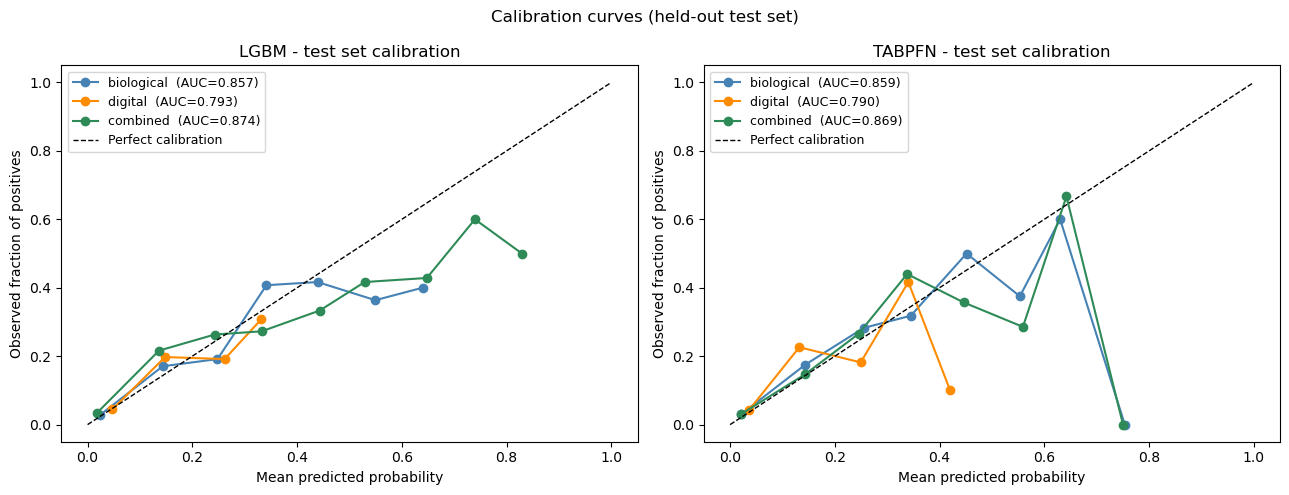

In [26]:
os.makedirs('outputs/figures', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {'biological': 'steelblue', 'digital': 'darkorange', 'combined': 'seagreen'}

for ax, model_type in zip(axes, ['lgbm', 'tabpfn']):
    for fs_name, color in colors.items():
        key = f'{model_type}_{fs_name}'
        prob_true, prob_pred = calibration_curve(y_test, test_results[key], n_bins=10, strategy='uniform')
        te_auc = roc_auc_score(y_test, test_results[key])
        ax.plot(prob_pred, prob_true, marker='o', color=color,
                label=f'{fs_name}  (AUC={te_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfect calibration')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Observed fraction of positives')
    ax.set_title(f'{model_type.upper()} - test set calibration')
    ax.legend(fontsize=9)

plt.suptitle('Calibration curves (held-out test set)', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/figures/calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()


TabPFN tracks the calibration diagonal slightly more closely than LightGBM in the 0.05-0.30
range where screening thresholds sit. Both become erratic above 0.40, which is expected with
low outcome prevalence and few participants at high predicted risk; this does not affect the
decision curves. Digital-only models compress predictions into a narrow probability range,
reflecting limited discriminative power. Whether TabPFN's modest calibration edge shifts the
decision curve is tested in notebook 04 - it does not.

## 8. Save Predictions

Both OOF (training set) and test set predictions are saved.

| File | Use |
|------|-----|
| `oof_predictions.pkl` | **Primary** - notebooks 04 and 05 use OOF as the main dataset. Each participant was scored by a model that never saw them, so estimates are unbiased across all training participants (n≈3,868). |
| `test_predictions.pkl` | **Sensitivity check** - fully independent held-out set (n≈968). Notebook 04 compares OOF and test curves to confirm agreement before relying on OOF for subgroup work. |

In [28]:
# OOF predictions on training set - primary dataset for notebooks 04 and 05
oof_pred_df = train_df[['participant_id', TARGET, 'cvd_composite']].copy()
for key, preds in oof_results.items():
    oof_pred_df[key] = preds

# Test set predictions - held-out, used as sensitivity check in notebook 04
test_pred_df = test_df[['participant_id', TARGET, 'cvd_composite']].copy()
for key, preds in test_results.items():
    test_pred_df[key] = preds

oof_pred_df.to_pickle('data/processed/oof_predictions.pkl')
test_pred_df.to_pickle('data/processed/test_predictions.pkl')
metrics_df.to_pickle('data/processed/metrics.pkl')

print(f"Saved: data/processed/oof_predictions.pkl   ({len(oof_pred_df):,} participants)")
print(f"Saved: data/processed/test_predictions.pkl  ({len(test_pred_df):,} participants)")
print(f"Saved: data/processed/metrics.pkl")
print(f"\nOOF prevalence  : {oof_pred_df[TARGET].mean():.1%}")
print(f"Test prevalence : {test_pred_df[TARGET].mean():.1%}")
print(f"Models saved    : {list(oof_results.keys())}")

Saved: data/processed/oof_predictions.pkl   (3,868 participants)
Saved: data/processed/test_predictions.pkl  (968 participants)
Saved: data/processed/metrics.pkl

OOF prevalence  : 7.5%
Test prevalence : 7.5%
Models saved    : ['lgbm_biological', 'tabpfn_biological', 'lgbm_digital', 'tabpfn_digital', 'lgbm_combined', 'tabpfn_combined']
